# GEONE - Variogram analysis and kriging for data in 3D (general)

Interpolate a data set in 3D, using ordinary kriging. Starting from a data set in 3D, the following is done:

- basic exploratory analysis: variogram cloud / experimental variogram
- fitting a covariance / variogram model, and cross-validation (LOO error)
- interpolation by ordinary kriging (OK), simple kriging (SK)
- sequential gaussian simulation (SGS) based on ordinary or simple kriging

## Import what is required

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import time

# import package 'geone'
import geone as gn

In [2]:
# Show version of python and version of geone
import sys 
print(sys.version_info)
print('geone version: ' + gn.__version__)

sys.version_info(major=3, minor=13, micro=7, releaselevel='final', serial=0)
geone version: 1.3.1


In [3]:
pv.set_jupyter_backend('static') # static plots
# pv.set_jupyter_backend('trame')  # 3D-interactive plots

## Preparation - build a data set in 3D

A data set in 3D is extracted from a Gaussian random field generated based on a known covariance model, called the *reference model* which will be considered as unknown further.

*Note: see the notebook `ex_general_multiGaussian.ipynb` for available covariance models and examples.*

In [4]:
cov_model_ref = gn.covModel.CovModel3D(elem=[
    ('spherical', {'w':9.5, 'r':[20, 10, 5]}), # elementary contribution (different ranges: anisotropic)
    ('nugget', {'w':0.5})                       # elementary contribution
    ], alpha=30.0, beta=-40.0, gamma=20.0, name='ref model (anisotropic)')

In [5]:
cov_model_ref

*** CovModel3D object ***
name = 'ref model (anisotropic)'
number of elementary contribution(s): 2
elementary contribution 0
    type: spherical
    parameters:
        w = 9.5
        r = [20, 10, 5]
elementary contribution 1
    type: nugget
    parameters:
        w = 0.5
angles: alpha = 30.0, beta = -40.0, gamma = 20.0 (in degrees)
    i.e.: the system Ox'''y''''z''', supporting the axes of the model (ranges),
    is obtained from the system Oxyz as follows:
        Oxyz      -- rotation of angle -alpha around Oz  --> Ox'y'z'
        Ox'y'z'   -- rotation of angle -beta  around Ox' --> Ox''y''z''
        Ox''y''z''-- rotation of angle -gamma around Oy''--> Ox'''y'''z'''
*****

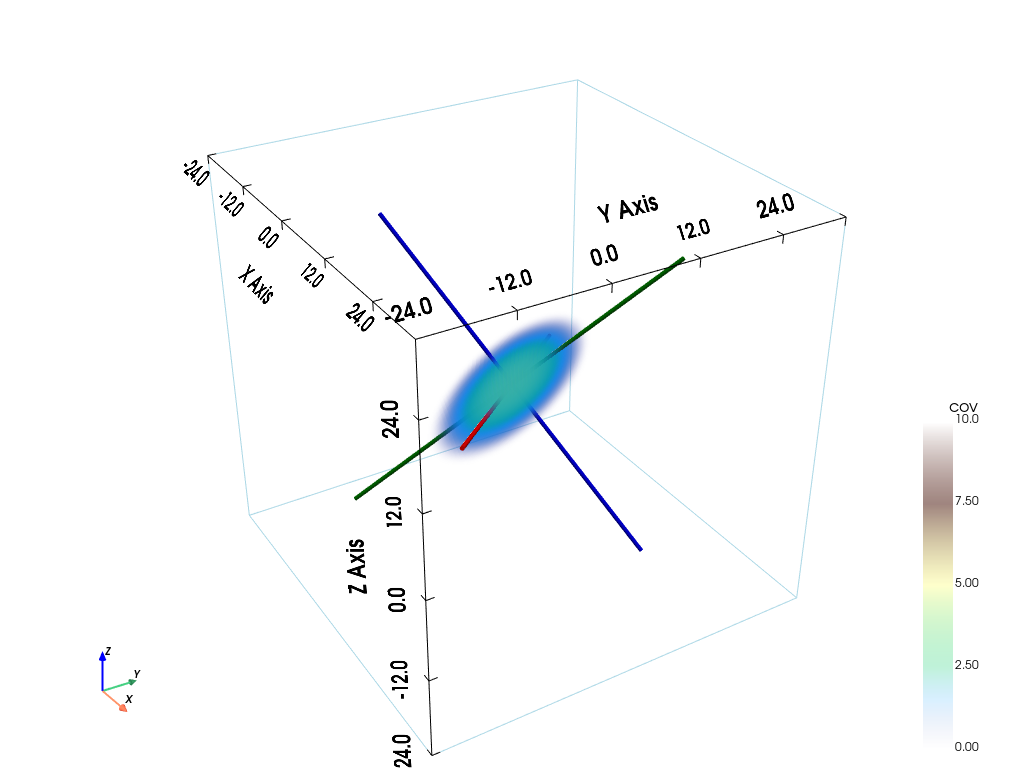

In [6]:
# Plot covariance model in 3D
pp = pv.Plotter()
# pp = pv.Plotter(notebook=False) # open a plotter and specifying 'notebook=False'
cov_model_ref.plot_model3d_volume(plotter=pp)
cpos = pp.show(cpos=(165, -100, 115), return_cpos=True) # position of the camera can be specified

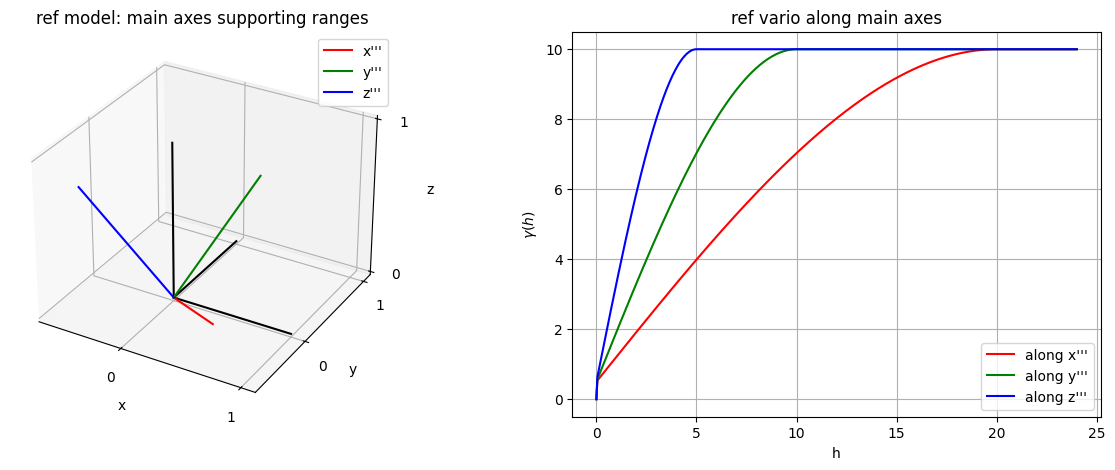

In [7]:
# Plot main axes supporting ranges and vario model curves along each main axis
fig = plt.figure(figsize=(15,5))

# ...plot main axes
fig.add_subplot(1,2,1, projection='3d')
cov_model_ref.plot_mrot(set_3d_subplot=False)
plt.title('ref model: main axes supporting ranges')

# ...plot variogram model curves along each main axis
fig.add_subplot(1,2,2)
cov_model_ref.plot_model_curves(vario=True)
plt.title('ref vario along main axes')
plt.show()

Generate a gaussian random field in 3D (see function `geone.grf.grf3D`), and extract data points:

- `n`: number of data points
- `x`: location of data points (2-dimensional array of shape `(n, 3)`, each row is a point)
- `v`: values at data points (1-dimensional array of length `n`)

In [8]:
# Simulation grid (domain)
nx, ny, nz = 65, 64, 60     # number of cells
sx, sy, sz = 0.5, 0.5, 0.5  # cell unit
ox, oy, oz = 0.0, 0.0, 0.0  # origin

# Reference simulation
np.random.seed(123)
ref = gn.grf.grf3D(cov_model_ref, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), nreal=1) 
    # 4d-array of shape 1 x nz x ny x nx

# Extract n points from the reference simulation
n = 150 # number of data points
ind = np.random.choice(nx*ny*nz, size=n, replace=False) # indexes of extracted grid cells
iz = ind//(nx*ny) # indexes along z-axis
ii = ind%(nx*ny)
iy = ii//nx # indexes along y-axis
ix = ii%nx  # indexes along x-axis
xc = ox + (ix + 0.5)*sx # x-coordinates of data points (centers of the extracted grid cells)
yc = oy + (iy + 0.5)*sy # y-coordinates of data points (centers of the extracted grid cells)
zc = oz + (iz + 0.5)*sz # z-coordinates of data points (centers of the extracted grid cells)
#xc = ox + (ind + np.random.random(n))*sx # x-coordinates of data points (within the extracted grid cells)
#yc = oy + (ind + np.random.random(n))*sy # y-coordinates of data points (within the extracted grid cells)
#zc = oz + (ind + np.random.random(n))*sz # z-coordinates of data points (within the extracted grid cells)

x = np.array((xc, yc, zc)).T # array of coordinates of data points (shape: n x 3)
v = ref[0].reshape(-1)[ind] # value at data points

In [9]:
# Preparation for plotting reference simulation and data points

# fill image (Img class from geone.img) for view
im_ref = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=1, val=ref)

# Color settings
cmap = 'terrain'

cmin = im_ref.vmin()[0] # min value in ref
cmax = im_ref.vmax()[0] # max value in ref

# Get colors for conditioning data according to their value and color settings
data_points_col = gn.imgplot.get_colors_from_values(v, cmap=cmap, cmin=cmin, cmax=cmax) 

# Set points to be plotted
data_points = pv.PolyData(x)
data_points['colors'] = data_points_col

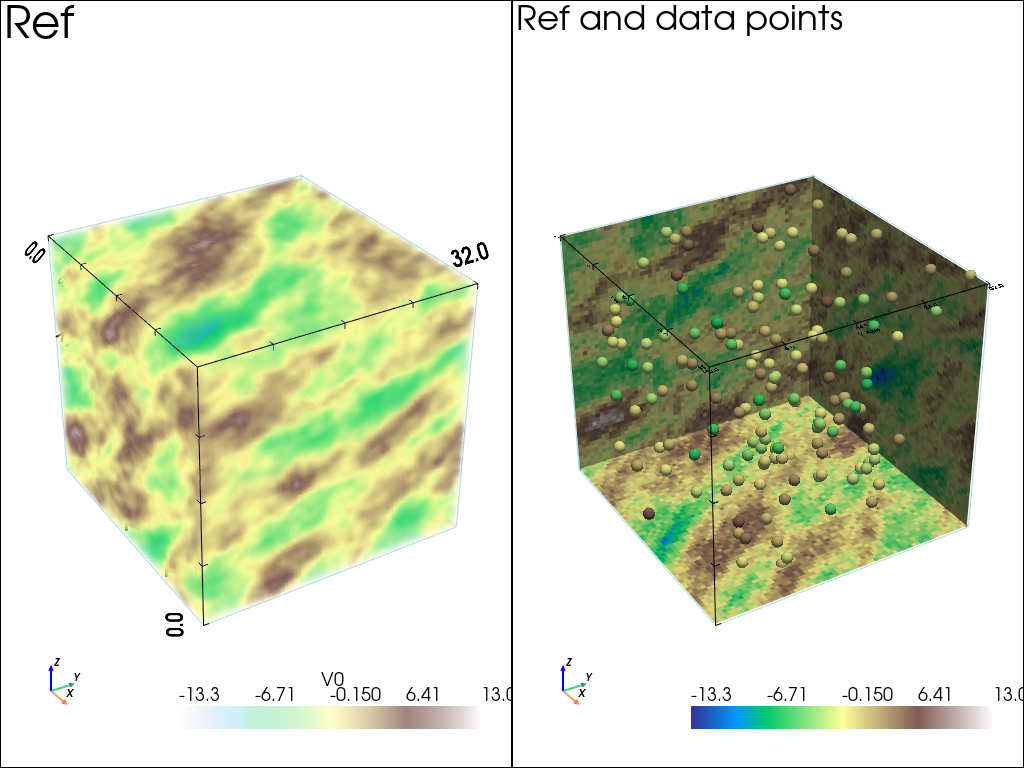

In [10]:
# Plot reference simulation and data points 

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(1,2), notebook=False)
# ... inline
pp = pv.Plotter(shape=(1,2))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_ref, 
    plotter=pp, 
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    text='Ref') # title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_slice(
    im_ref, 
    plotter=pp, 
    slice_normal_x=ox+0.5*sx,
    slice_normal_y=oy+(ny-0.5)*sy,
    slice_normal_z=oz+0.5*sz,
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text='Ref and data points')

pp.add_mesh(data_points, rgb=True, point_size=12., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

## Start from a data set in 3D

- `n`: number of data points
- `x`: location of data points (2-dimensional array of shape `(n, 3)`, each row is a point)
- `v`: values at data points (1-dimensional array of length `n`)

Visualise the data set and the histogram of values.

In [11]:
# Set data_points
data_points = pv.PolyData(x)
data_points['data value'] = v

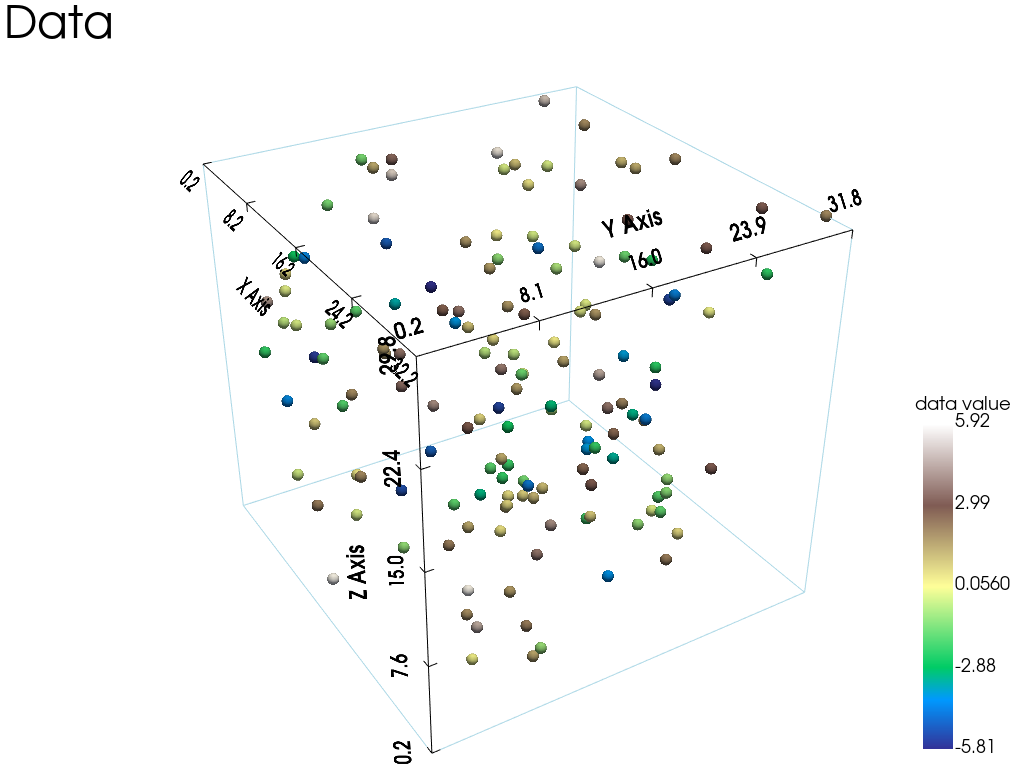

In [12]:
# Plot data points in 3D

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(notebook=False)
# ... inline
pp = pv.Plotter()

pp.add_mesh(data_points, cmap=cmap, point_size=12., render_points_as_spheres=True, 
            scalar_bar_args={'vertical':True, 'title_font_size':18})
pp.add_mesh(data_points.outline())
pp.show_bounds()
pp.add_text('Data')

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

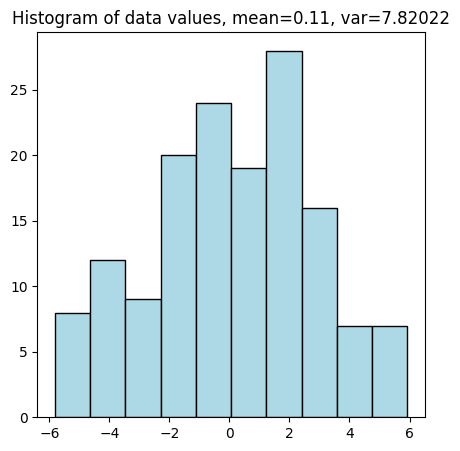

In [13]:
# Plot histogram of data values
plt.figure(figsize=(5,5))
plt.hist(v, color='lightblue', edgecolor='black')
plt.title('Histogram of data values, mean={:.2g}, var={:2g}'.format(np.mean(v), np.var(v)))
plt.show()

### Model fitting
The function `geone.covModel.covModel3D_fit` is used to fit a covariance model in 3D (class `geone.covModel.CovModel3D`).

This function takes as first argument the location of the data points, as second argument the values at the data points, and at third argument a covariance model in 3D with given type of elementary contributions and with parameters to fit set to `nan`. It returns the optimal covariance model and the vector of optimal parameters.

This function is based on the function `curve_fit` from `scipy.optimize` module. It fits the curve of the variogram model to the points $(h, \gamma(h))$, where $h$ is the lag between a pair of data points and $\gamma(h)$ is the half of the square of the difference of the values at these points. Hence, the fitting does not depend on the experimental variogram (see further), *i.e.* on the choice of direction or classes for the lags.

The function `geone.covModel.covModel3D_fit` also takes the keyword argument `hmax`, which specifies the maximal distance between two data points to be integrated in the fitting. Note that a plot of the optimal model returned is made by default (keyword argument `make_plot=True`).

#### Bounds for parameters to fit
Bounds for parameters to fit can be specified to avoid meaningless optimal parameters returned (*e.g.* negative weight or range). Such bounds are given to the function `geone.covModel.covModel3D_fit` (and then to the function `curve_fit` from `scipy.optimize`) via the keyword arguments `bounds=(<array of lower bounds>, <array of upper bounds>)`, where the arrays of lower / upper bounds have the same length as the vector of parameters to fit, with the $i-$th entry corresponding to the $i$-th parameter to fit (set to `nan`) in the covariance model passed as third argument. Note also that the keyword argument `p0` allows to specify a vector of initial parameters (see doc of function `curve_fit`).

In [14]:
cov_model_to_optimize = gn.covModel.CovModel3D(
    elem=[('gaussian',    {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('spherical',   {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('exponential', {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('nugget',      {'w':np.nan})                        # elementary contribution
         ], alpha=np.nan, beta=np.nan, gamma=np.nan, name='')

cov_model_opt, popt = gn.covModel.covModel3D_fit(x, v, cov_model_to_optimize, #hmax=150,
    bounds=([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  .1, -90, -90, -90],  # min value for param. to fit
            [20, 30, 30, 30, 20, 30, 30, 30, 20, 30, 30, 30,   2,  90,  90,  90]), # max value for param. to fit
             # gaus. contr.,   sph. contr. ,   exp. contr. , nug., angles: alpha, beta, gamma
    make_plot=False)
cov_model_opt

*** CovModel3D object ***
name = ''
number of elementary contribution(s): 4
elementary contribution 0
    type: gaussian
    parameters:
        w = 3.2713744321470387e-06
        r = [np.float64(17.01216322185156), np.float64(11.623385374676833), np.float64(0.5278624595601151)]
elementary contribution 1
    type: spherical
    parameters:
        w = 7.650160279761836
        r = [np.float64(29.998859625669176), np.float64(5.735934378015639), np.float64(8.863216853734368)]
elementary contribution 2
    type: exponential
    parameters:
        w = 0.2545260407384066
        r = [np.float64(0.19267474342278815), np.float64(14.826615761153587), np.float64(21.38686459424588)]
elementary contribution 3
    type: nugget
    parameters:
        w = 0.10056057815496205
angles: alpha = 52.70617441678761, beta = 45.475254934618846, gamma = 10.848097969906284 (in degrees)
    i.e.: the system Ox'''y''''z''', supporting the axes of the model (ranges),
    is obtained from the system Oxyz as foll

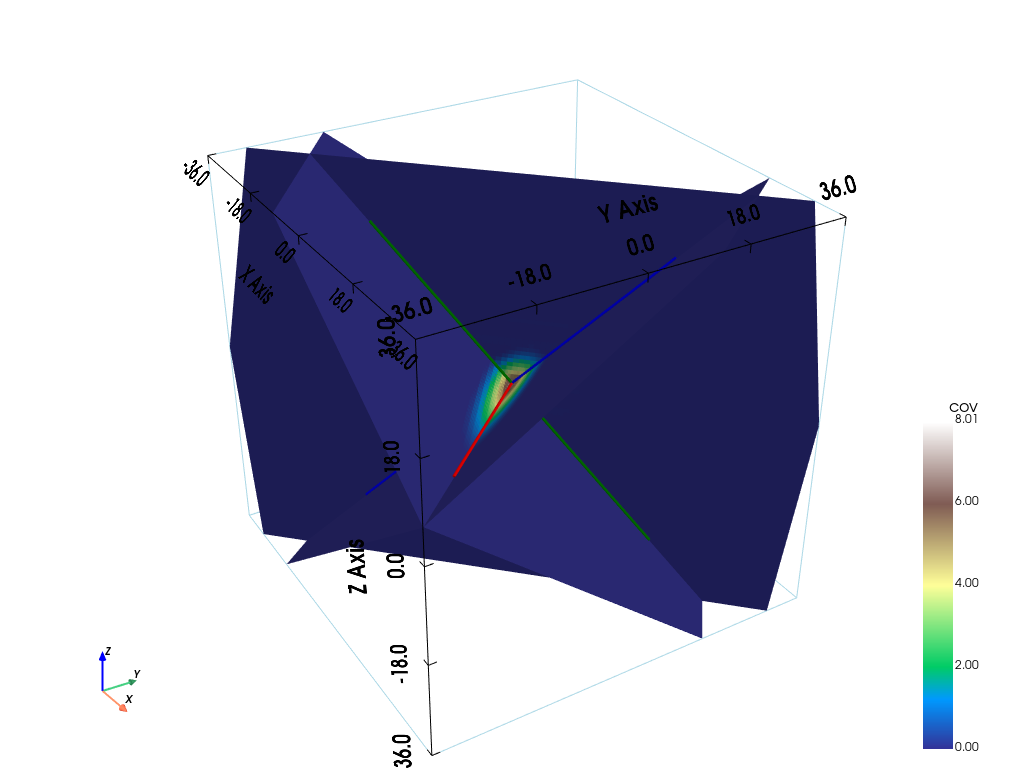

In [15]:
# Plot covariance model in 3D
#  slice orthogonal to main axes in a 3D block
pp = pv.Plotter()
# pp = pv.Plotter(notebook=False) # open a plotter and specifying 'notebook=False'
cov_model_opt.plot_model3d_slice(plotter=pp)
cpos = pp.show(cpos=(165, -100, 115), return_cpos=True) # position of the camera can be specified

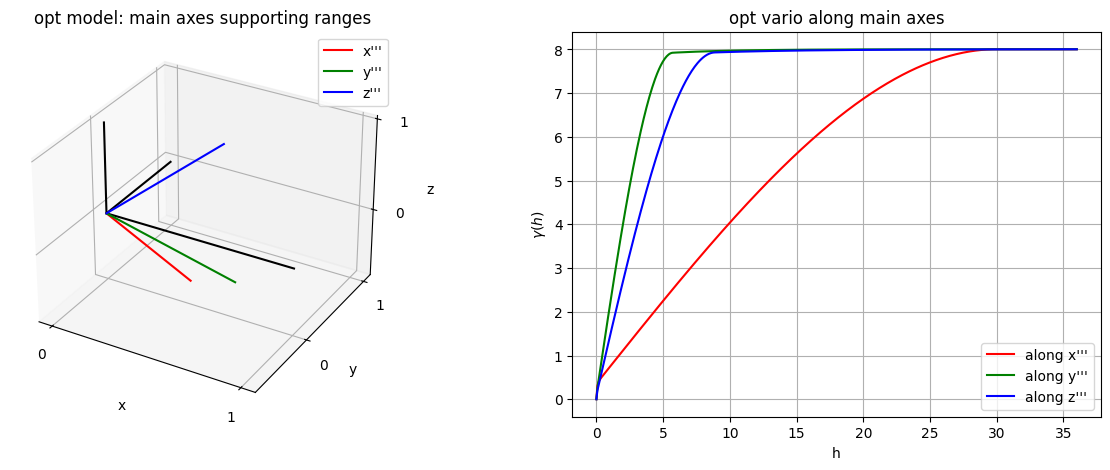

In [16]:
# Plot main axes supporting ranges and vario model curves along each main axis
fig = plt.figure(figsize=(15,5))

# ...plot main axes
fig.add_subplot(1,2,1, projection='3d')
cov_model_opt.plot_mrot(set_3d_subplot=False)
plt.title('opt model: main axes supporting ranges')

# ...plot variogram model curves along each main axis
fig.add_subplot(1,2,2)
cov_model_opt.plot_model_curves(vario=True)
plt.title('opt vario along main axes')
plt.show()

### Check with the experimental variograms in the main directions (derived from optimal angles retrieved)
The function `geone.covModel.variogramExp3D` computes three directional exprimental variograms for a data set in 3D: one along each main axis ($x'''$, $y'''$ and $z'''$). The system $Ox'''y'''z'''$ is defined from the angle alpha, beta and gamma (keyword arguments `alpha`, `beta` and `gamma`) in the same way as for covariance model in 3D.

The keyword arguments `tol_dist` and `tol_angle` allow to control which pair of data points are taken into account in the two experimental variograms: a pair of points $(x(i), x(j))$ is in the directional variogram cloud along axis $x'''$ (resp. $y'''$, $z'''$) iff, given the lag vector $h = x(i) - x(j)$:

- the distance from the end of vector $h$ issued from origin to that axis is less than or equal to `tol_dist` and
- the angle between $h$ and that axis is less than or equal to `tol_angle`

The maximal distance between two data points to be integrated can be specified by the keyword argument `hmax` (vector of three floats one for each axis), and the classes can be customized by using the keyword arguments `ncla`, `cla_center`, `cla_length` (each one is a vector of length 3, specification for each axis), in a similar way as explained for the function `geone.covModel.variogramExp1D` (see jupyter notebook `ex_vario_analysis_data1D`).

The function `geone.covModel.variogramExp3D` returns three experimental variograms "unidimensional" (see function `geone.covModel.variogramExp1D` and jupyter notebook `ex_vario_analysis_data1D`).

**Note:** the function `geone.covModel.variogramCloud3D` allows to compute variogram clouds along the main axes in a similar way.

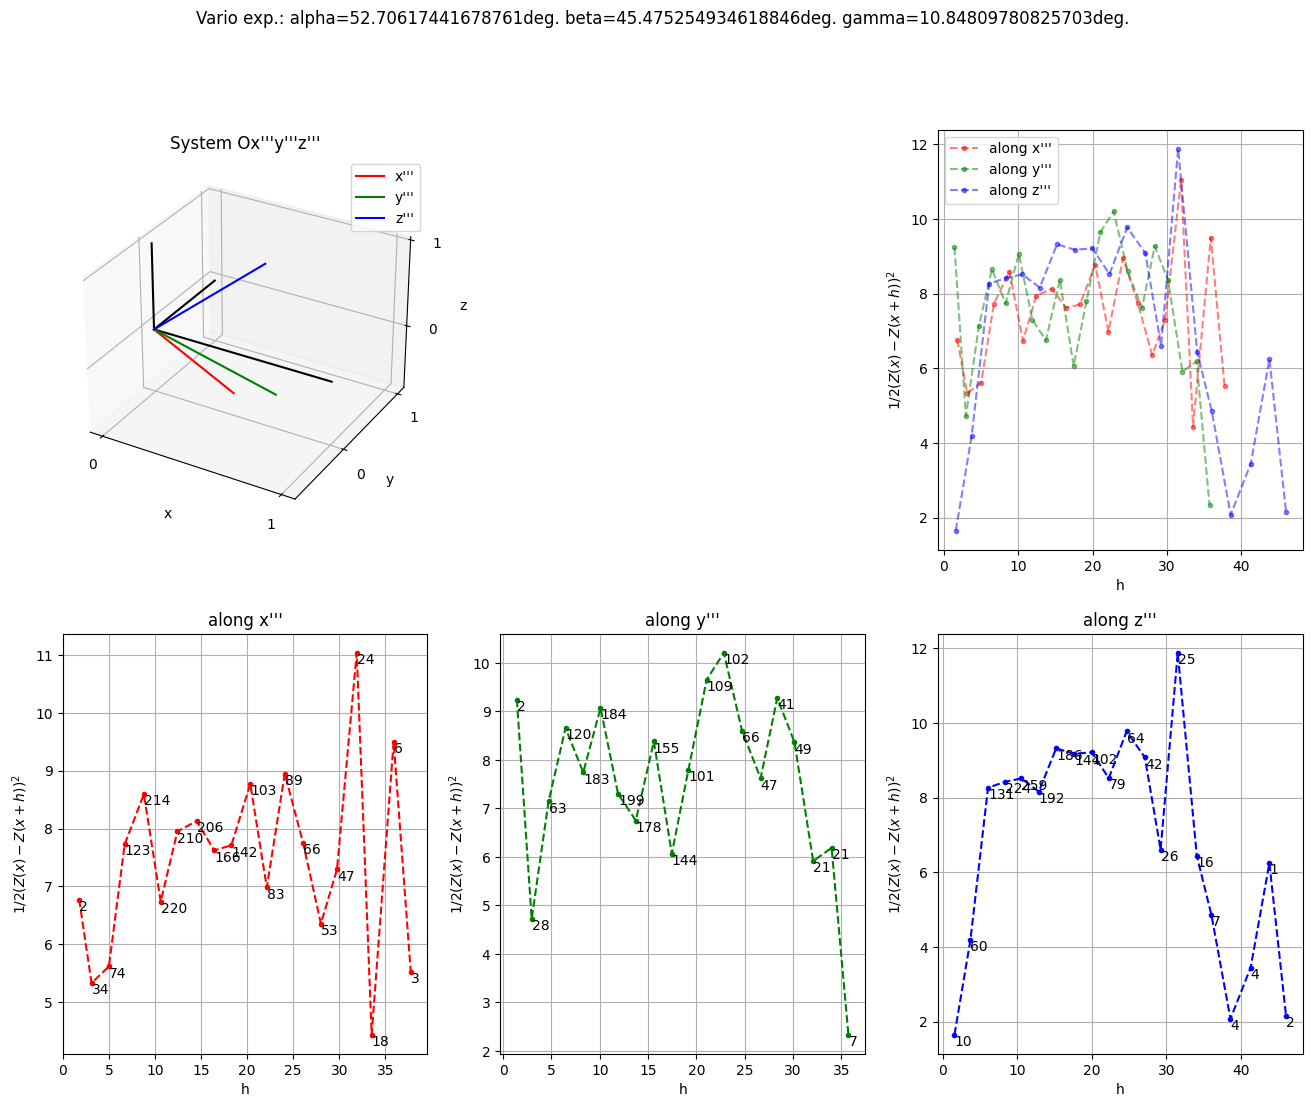

In [17]:
alpha_opt, beta_opt, gamma_opt = popt[-3:]
(hexp1, gexp1, cexp1), (hexp2, gexp2, cexp2), (hexp3, gexp3, cexp3) = gn.covModel.variogramExp3D(x, v, 
    alpha=alpha_opt, beta=beta_opt, gamma=gamma_opt, ncla=(20,20,20), make_plot=True, figsize=(16,12))

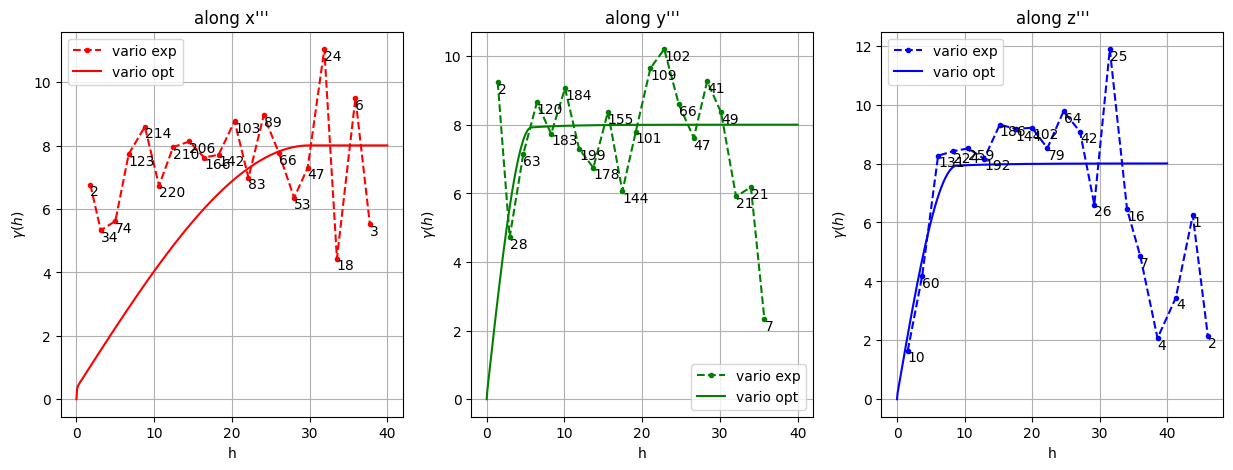

In [18]:
plt.subplots(1,3,figsize=(15,5))
plt.subplot(1,3,1)
gn.covModel.plot_variogramExp1D(hexp1, gexp1, cexp1, c='red', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=1, hmax=40, c='red', label='vario opt')
plt.legend()
plt.title("along x'''")

plt.subplot(1,3,2)
gn.covModel.plot_variogramExp1D(hexp2, gexp2, cexp2, c='green', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=2, hmax=40, c='green', label='vario opt')
plt.legend()
plt.title("along y'''")

plt.subplot(1,3,3)
gn.covModel.plot_variogramExp1D(hexp3, gexp3, cexp3, c='blue', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=3, hmax=40, c='blue', label='vario opt')
plt.legend()
plt.title("along z'''")

plt.show()

### Cross-validation of covariance model by leave-one-out error
The function `geone.covModel.cross_valid_loo` makes a cross-validation test by leave-one-out (LOO) error. Here, a data set in 3D and a covariance model in 3D are given.

See jupyter notebook `ex_vario_analysis_data1D` for more details about this function.

----- CRPS (negative; the larger, the better) -----
   mean = -1.409
   def. = -0.6535
----- 1) "Normal law test for mean of normalized error" -----
   p-value = 0.8361
   success = True (wrt significance level 0.05)
      (-> model has no reason to be rejected)
----- 2) "Chi-square test for sum of squares of normalized error" -----
   p-value = 0.002865
   success = False (wrt significance level 0.05)
      -> model should be REJECTED
----- Statistics of normalized error -----
   mean     = -0.01689 (should be close to 0)
   std      = 1.161 (should be close to 1)
   skewness = 0.1162 (should be close to 0)
   excess kurtosis = -0.3154 (should be close to 0)


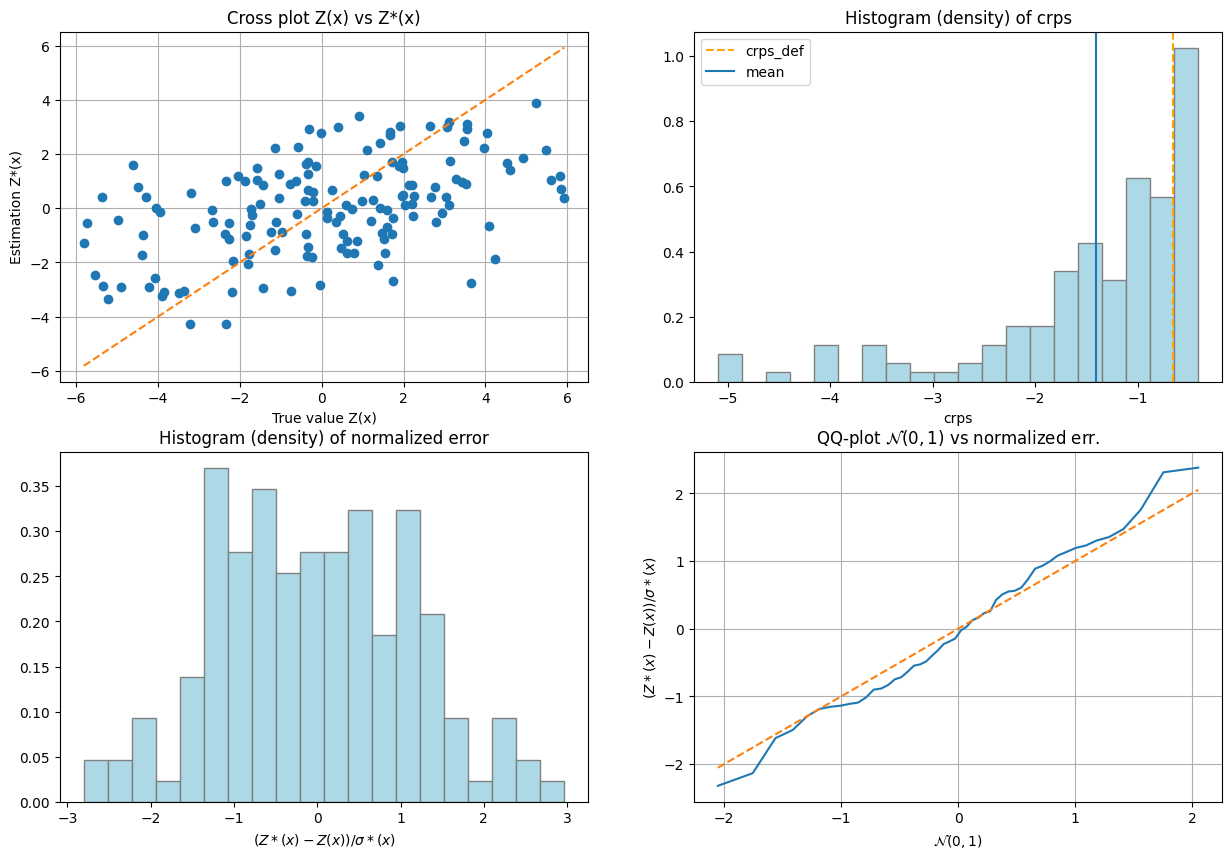

In [19]:
# Interpolation by simple kriging
cv_est1, cv_std1, crps1, crps_def1, pvalue1, success1 = gn.covModel.cross_valid_loo(
                                        x, v, cov_model_opt,
                                        interpolator=gn.covModel.krige, 
                                        interpolator_kwargs={'use_unique_neighborhood':True},
                                        print_result=True, make_plot=True, figsize=(15,10), nbins=20)
plt.show()

The second test failed, then the covariance model should be rejected! Then, the search for a convenient covariance model continues.

/home/julien/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/julien/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


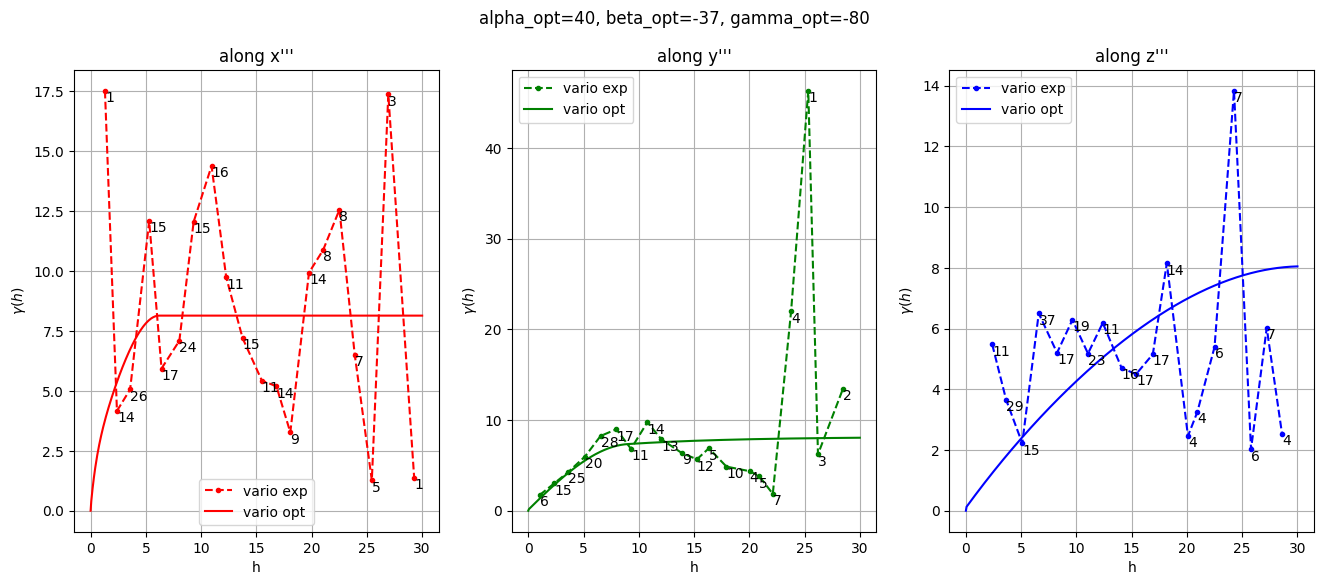

----- CRPS (negative; the larger, the better) -----
   mean = -1.346
   def. = -0.6535
----- 1) "Normal law test for mean of normalized error" -----
   p-value = 0.8484
   success = True (wrt significance level 0.05)
      (-> model has no reason to be rejected)
----- 2) "Chi-square test for sum of squares of normalized error" -----
   p-value = 0.222
   success = True (wrt significance level 0.05)
      (-> model has no reason to be rejected)
----- Statistics of normalized error -----
   mean     = -0.01561 (should be close to 0)
   std      = 1.042 (should be close to 1)
   skewness = 0.07152 (should be close to 0)
   excess kurtosis = -0.437 (should be close to 0)


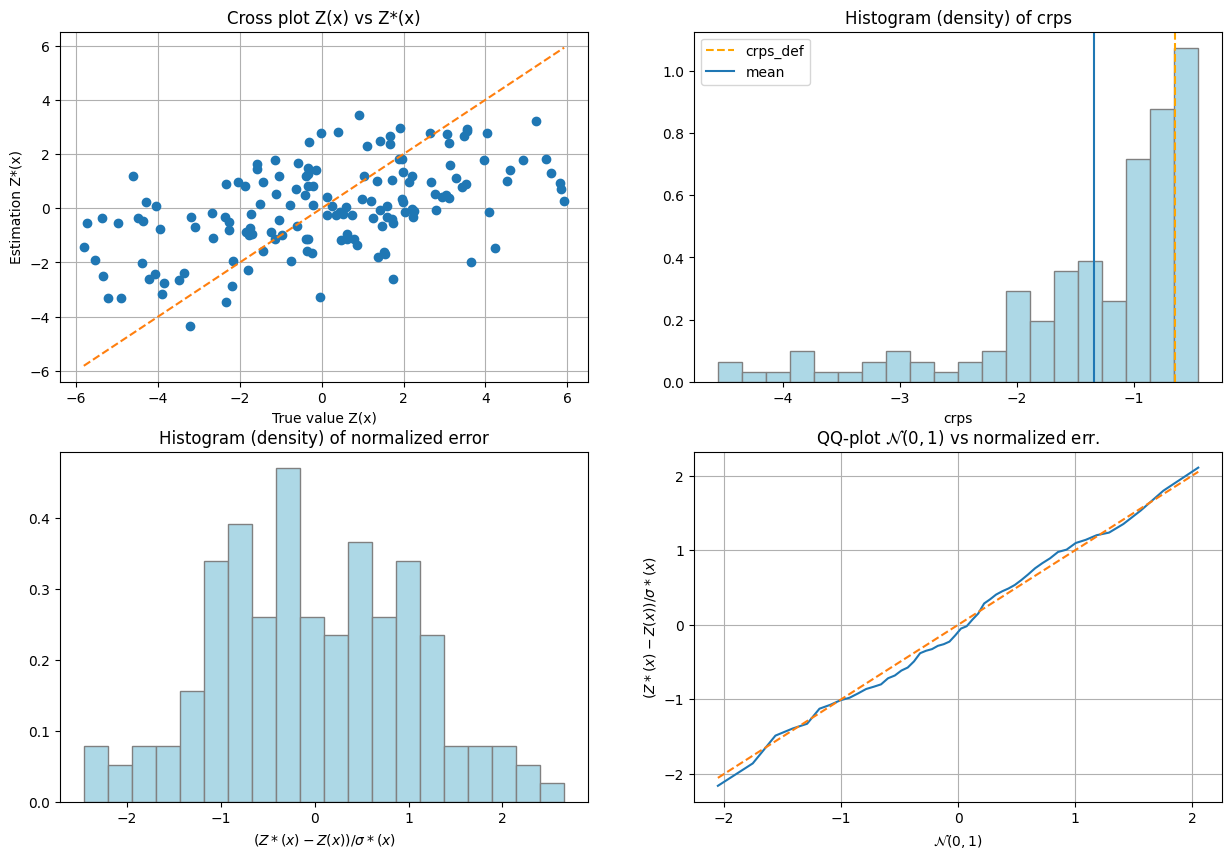

In [20]:
# %%script false --no-raise-error # skip this cell! (comment this line to run the cell)

# Model fitting 
cov_model_to_optimize = gn.covModel.CovModel3D(
    elem=[('gaussian',    {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('spherical',   {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('exponential', {'w':np.nan, 'r':[np.nan, np.nan, np.nan]}), # elementary contribution
          ('nugget',      {'w':np.nan})                        # elementary contribution
         ], alpha=np.nan, beta=np.nan, gamma=np.nan, name='')

# New optim. while limiting the distance between pair of points to 30 (hmax=30)
# and limiting max ranges to 20 (instead of 30 above)
hmax = 30
cov_model_opt, popt = gn.covModel.covModel3D_fit(x, v, cov_model_to_optimize, hmax=hmax,
    bounds=([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  .1, -85, -85, -85],  # min value for param. to fit
            [20, 30, 30, 30, 20, 30, 30, 30, 20, 30, 30, 30,   2,  80,  80,  80]), # max value for param. to fit
             # gaus. contr.,   sph. contr. ,   exp. contr. , nug., angles: alpha, beta, gamma
    make_plot=False)

# Experimental variograms
alpha_opt, beta_opt, gamma_opt = popt[-3:]
(hexp1, gexp1, cexp1), (hexp2, gexp2, cexp2), (hexp3, gexp3, cexp3) = gn.covModel.variogramExp3D(x, v, 
    alpha=alpha_opt, beta=beta_opt, gamma=gamma_opt, hmax=(hmax, hmax, hmax), ncla=(20, 20, 20), make_plot=False)

# Figure: optimal vario and exp. vario along main axes given by alpha_opt, beta_opt, gamma_opt
plt.subplots(1,3,figsize=(16,6))
plt.subplot(1,3,1)
gn.covModel.plot_variogramExp1D(hexp1, gexp1, cexp1, c='red', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=1, hmax=hmax, c='red', label='vario opt')
plt.legend()
plt.title("along x'''")

plt.subplot(1,3,2)
gn.covModel.plot_variogramExp1D(hexp2, gexp2, cexp2, c='green', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=2, hmax=hmax, c='green', label='vario opt')
plt.legend()
plt.title("along y'''")

plt.subplot(1,3,3)
gn.covModel.plot_variogramExp1D(hexp3, gexp3, cexp3, c='blue', label='vario exp')
cov_model_opt.plot_model_one_curve(vario=True, main_axis=3, hmax=hmax, c='blue', label='vario opt')
plt.legend()
plt.title("along z'''")

plt.suptitle('alpha_opt={:.2g}, beta_opt={:.2g}, gamma_opt={:.2g}'.format(alpha_opt, beta_opt, gamma_opt))
plt.show()

# Cross-validation
# Interpolation by simple kriging (adapt also parameters (interpolator_kwargs) if needed)
cv_est1, cv_std1, crps1, crps_def1, pvalue1, success1 = gn.covModel.cross_valid_loo(
                                        x, v, cov_model_opt,
                                        interpolator=gn.covModel.krige, 
                                        interpolator_kwargs={'use_unique_neighborhood':True},
                                        print_result=True, make_plot=True, figsize=(15,10), nbins=20)
plt.show()


**Note:** the following illustrations are similar to what is done in the jupyter notebook `ex_vario_analysis_data3D_1_omnidirectional`.

## Data interpolation by (simple or ordinary) kriging: function `geone.covModel.krige`
See notebook `ex_vario_analysis_data1D_1.ipynb`.


In [21]:
# Define points xu where to interpolate
# ... location of the 3D-grid used to build the data set (but it could be different)
xcu = ox + (np.arange(nx)+0.5)*sx # x-coordinates of points
ycu = oy + (np.arange(ny)+0.5)*sy # y-coordinates of points
zcu = oz + (np.arange(nz)+0.5)*sz # z-coordinates of points
zzcu, yycu, xxcu = np.meshgrid(zcu, ycu, xcu, indexing='ij')
xu = np.array((xxcu.reshape(-1), yycu.reshape(-1), zzcu.reshape(-1))).T # 2-dimensional array 
                                                                        # of shape nx*ny*nz x 3

# Ordinary kriging
t1 = time.time()
vu, vu_std = gn.covModel.krige(x, v, xu, cov_model_opt, method='ordinary_kriging', use_unique_neighborhood=True)
# vu:     1-dimensional array, kriging estimates at location xu
# vu_std: 1-dimensional array, kriging standard deviation at location xu
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

# Fill image (Img class from geone.img) for view
#   variable 0: kriging estimates
#   variable 1: kriging standard deviation
im_krig = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=2, val=np.array((vu, vu_std)))

Elapsed time: 5.2 sec


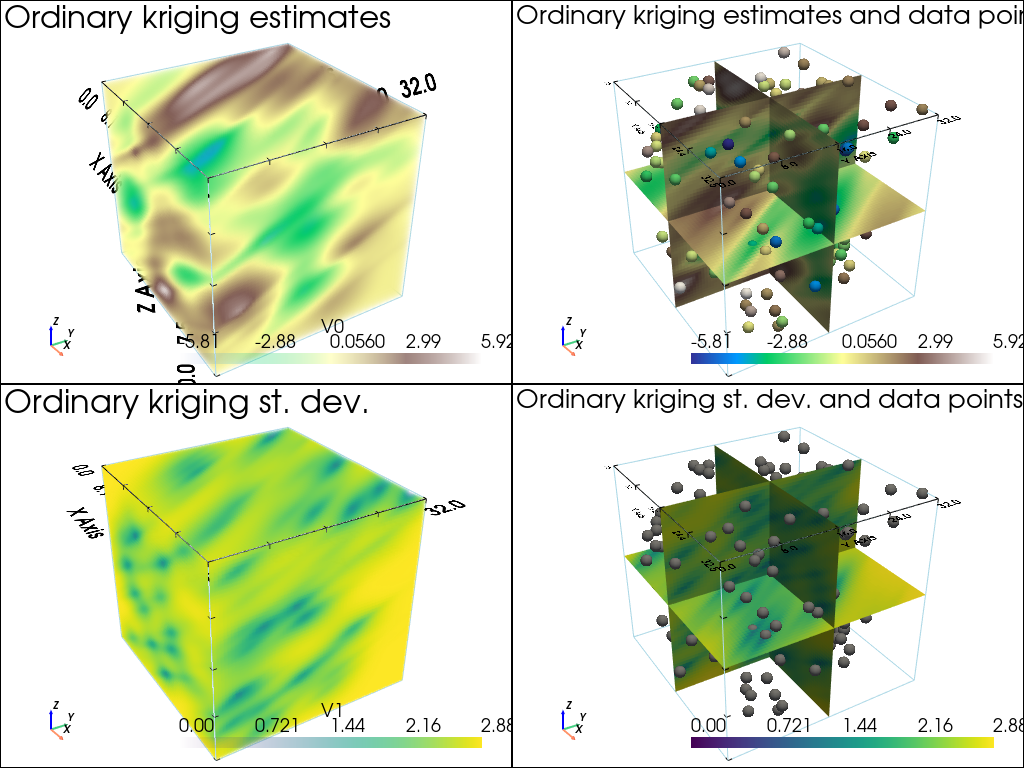

In [22]:
# Color settings
cmap = 'terrain'

cmin = im_krig.vmin()[0] # min value of kriging estimates
cmax = im_krig.vmax()[0] # max value of kriging estimates

# Get colors for conditioning data according to their value and color settings
data_points_col = gn.imgplot.get_colors_from_values(v, cmap=cmap, cmin=cmin, cmax=cmax) 

# Set points to be plotted
data_points = pv.PolyData(x)
data_points['colors'] = data_points_col

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(2,2), notebook=False)
# ... inline
pp = pv.Plotter(shape=(2,2))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=0, 
    plotter=pp, 
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    text='Ordinary kriging estimates') # title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=0, 
    plotter=pp,
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text='Ordinary kriging estimates and data points') # title                          
pp.add_mesh(data_points, rgb=True, point_size=12., render_points_as_spheres=True)

pp.subplot(1, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=1, 
    plotter=pp, 
    cmap='viridis',
    show_bounds=True, # show axes and ticks around the 3D box
    text='Ordinary kriging st. dev.') # title

pp.subplot(1, 1)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=1, 
    plotter=pp,
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap='viridis',
    show_bounds=True, # show axes and ticks around the 3D box
    scalar_bar_kwargs={'title':' '}, # distinct title in each subplot for correct display!
    text='Ordinary kriging st. dev. and data points') # title                          
pp.add_mesh(data_points, color='gray', point_size=12., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

In [23]:
# Define points xu where to interpolate
# ... location of the 3D-grid used to build the data set (but it could be different)
xcu = ox + (np.arange(nx)+0.5)*sx # x-coordinates of points
ycu = oy + (np.arange(ny)+0.5)*sy # y-coordinates of points
zcu = oz + (np.arange(nz)+0.5)*sz # z-coordinates of points
zzcu, yycu, xxcu = np.meshgrid(zcu, ycu, xcu, indexing='ij')
xu = np.array((xxcu.reshape(-1), yycu.reshape(-1), zzcu.reshape(-1))).T # 2-dimensional array 
                                                                        # of shape nx*ny*nz x 3

# Simple kriging
t1 = time.time()
vu, vu_std = gn.covModel.krige(x, v, xu, cov_model_opt, method='simple_kriging', use_unique_neighborhood=True)
# vu:     1-dimensional array, kriging estimates at location xu
# vu_std: 1-dimensional array, kriging standard deviation at location xu
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

# Fill image (Img class from geone.img) for view
#   variable 0: kriging estimates
#   variable 1: kriging standard deviation
im_krig = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=2, val=np.array((vu, vu_std)))

Elapsed time: 5.6 sec


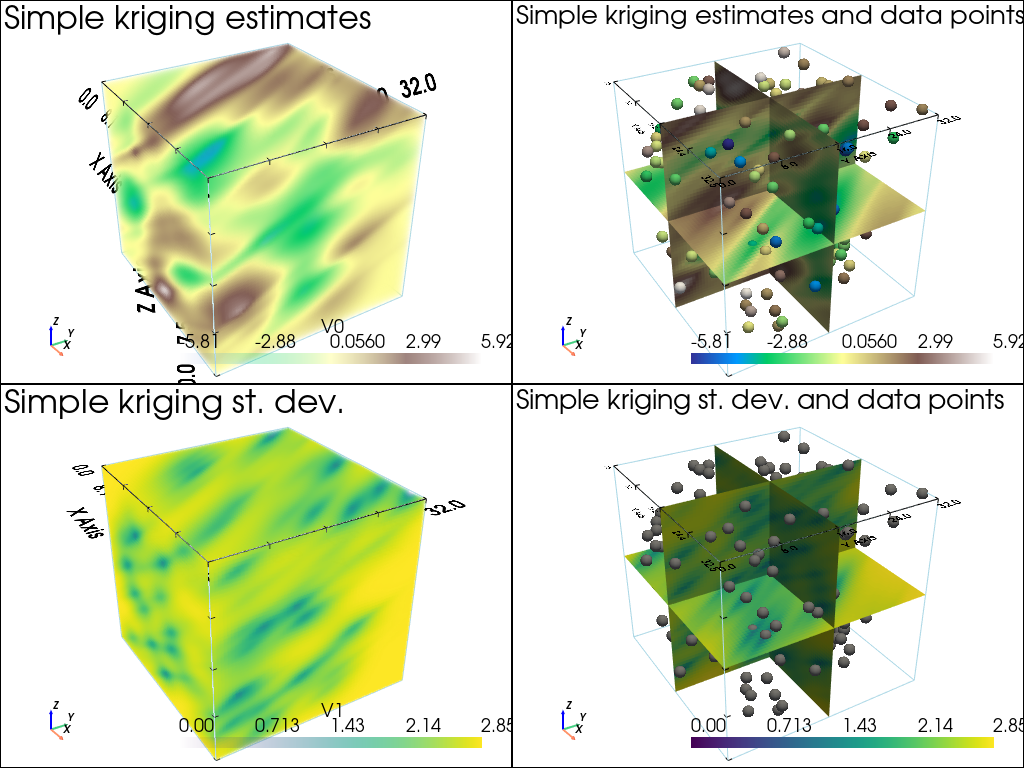

In [24]:
# Color settings
cmap = 'terrain'

cmin = im_krig.vmin()[0] # min value of kriging estimates
cmax = im_krig.vmax()[0] # max value of kriging estimates

# Get colors for conditioning data according to their value and color settings
data_points_col = gn.imgplot.get_colors_from_values(v, cmap=cmap, cmin=cmin, cmax=cmax) 

# Set points to be plotted
data_points = pv.PolyData(x)
data_points['colors'] = data_points_col

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(2,2), notebook=False)
# ... inline
pp = pv.Plotter(shape=(2,2))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=0, 
    plotter=pp, 
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    text='Simple kriging estimates') # title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=0, 
    plotter=pp,
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap, cmin=cmin, cmax=cmax,
    show_bounds=True, # show axes and ticks around the 3D box
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text='Simple kriging estimates and data points') # title                          
pp.add_mesh(data_points, rgb=True, point_size=12., render_points_as_spheres=True)

pp.subplot(1, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=1, 
    plotter=pp, 
    cmap='viridis',
    show_bounds=True, # show axes and ticks around the 3D box
    text='Simple kriging st. dev.') # title

pp.subplot(1, 1)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=1, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap='viridis',
    show_bounds=True, # show axes and ticks around the 3D box
    scalar_bar_kwargs={'title':' '}, # distinct title in each subplot for correct display!
    text='Simple kriging st. dev. and data points') # title                          
pp.add_mesh(data_points, color='gray', point_size=12., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

## Kriging estimation and simulation in a grid
The function above (`gn.covModel.krige` and `gn.covModel.sgs[_mp]`) should not be used for kriging and SGS in a regular grid. Use the dedicated functions (much faster):
- `geone.geosclassicinterface.estimate`: estimation (kriging) in a grid
- `geone.geosclassicinterface.simulate`: simulation (SGS) in a grid
- `geone.grf.krige<d>D`: estimation (kriging) in a `<d>`-dimensional grid
- `geone.grf.grf<d>D`: simulation (SGS) in a `<d>`-dimensional grid

*Note: the functions of the module `geone.grf` are based on "Fast Fourier Transform" and allow for simple kriging only, and do not handle error on data or inequality data.*

*Note: the function `geone.multiGaussian.multiGaussianRun` can be used as a wrapper to run the functions above.*

See notebook `ex_vario_analysis_data1D_1.ipynb`.

## Examples

### Estimation using the function `geone.covModel.krige`

In [25]:
t1 = time.time()
vu, vu_std = gn.covModel.krige(x, v, xu, cov_model_opt, method='simple_kriging', use_unique_neighborhood=True)
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

Elapsed time: 5.2 sec


### Estimation using the function `geone.grf.krige3D`
Via the function `geone.multiGaussian.multiGaussianRun`, with keyword arguments `mode='estimation', algo='fft'`.

In [26]:
t1 = time.time()
im_grf = gn.multiGaussian.multiGaussianRun(
                cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
                x=x, v=v,
                mode='estimation', algo='fft', output_mode='img')
# # Or:
# vu_grf, vu_std_grf = gn.grf.krige3D(
#                 cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
#                 x=x, v=v)
# im_grf = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=2, val=np.array((vu_grf, vu_std_grf)))
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

krige3D: compute circulant embedding...
krige3D: embedding dimension: 128 x 128 x 128
krige3D: compute FFT of circulant matrix...
krige3D: compute covariance matrix (rAA) for conditioning locations...
krige3D: compute covariance matrix (rBA) for non-conditioning / conditioning locations...
krige3D: compute rBA * rAA^(-1)...
krige3D: compute kriging estimates...
krige3D: compute kriging standard deviation ...
Elapsed time: 2.1 sec


### Estimation using the function `geone.geosclassicinterface.estimate`
Via the function `geone.multiGaussian.multiGaussianRun`, with keyword arguments `mode='estimation', algo='classic'`.

In [27]:
t1 = time.time()
im_gci = gn.multiGaussian.multiGaussianRun(
                cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
                x=x, v=v,
                mode='estimation', algo='classic', output_mode='img',
                method='simple_kriging', 
                nneighborMax=24,
                nthreads=8)
# # Or:
# estim_gci = gn.geosclassicinterface.estimate(
#                 cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
#                 x=x, v=v,
#                 method='simple_kriging', 
#                 nneighborMax=24,
#                 nthreads=8)
# im_gci = estim_gci['image']
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

estimate: pre-process data done: final number of data points : 150, inequality data points: 0
estimate: computational resources: nthreads = 8, nproc_sgs_at_ineq = 8
estimate: (Step 1) no inequality data
estimate: (Step 2) set new dataset gathering data and inequality data locations...
estimate: (Step 3) do kriging at the center of grid cells containing at least one data point...
estimate: (Step 4) do kriging on the grid (at cell centers) using data points at cell centers...
estimate: call `run_MPDSOMPGeosClassicSim` [1 process of 8 thread(s) (OpenMP)] ...
estimate: `run_MPDSOMPGeosClassicSim` [1 process] complete
estimate: warnings encountered (5285 times in all):
#  1: WARNING 02001: a neigbhor has been dropped (solving kriging system)
#  2: WARNING 02015: solving kriging system fails (do as if no neighbor)
Elapsed time: 21 sec


### Plot results of estimation

In [28]:
# Fill images (Img class from geone.img) for view
#   variable 0: kriging estimates
#   variable 1: kriging standard deviation
im_krig = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=2, val=np.array((vu, vu_std)))

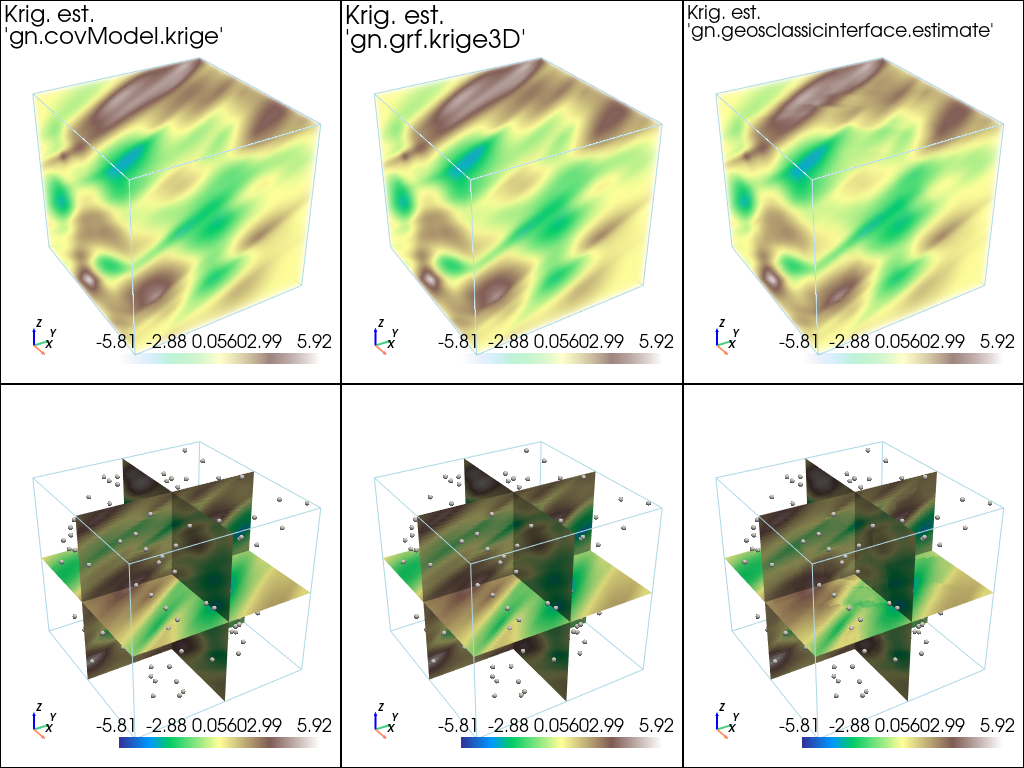

In [29]:
# Plot kriging estimates

# Color settings
cmap = 'terrain'

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(2,3), notebook=False)
# ... inline
pp = pv.Plotter(shape=(2,3))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=0, 
    plotter=pp, 
    cmap=cmap,
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text="Krig. est.\n'gn.covModel.krige'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_volume(
    im_grf, iv=0, 
    plotter=pp, 
    cmap=cmap,
    scalar_bar_kwargs={'title':' '}, # distinct title in each subplot for correct display!
    text="Krig. est.\n'gn.grf.krige3D'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(0, 2)
gn.imgplot3d.drawImage3D_volume(
    im_gci, iv=0, 
    plotter=pp, 
    cmap=cmap,
    scalar_bar_kwargs={'title':'  '}, # distinct title in each subplot for correct display!
    text="Krig. est.\n'gn.geosclassicinterface.estimate'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(1, 0)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'   '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 1)
gn.imgplot3d.drawImage3D_slice(
    im_grf, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'    '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 2)
gn.imgplot3d.drawImage3D_slice(
    im_gci, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'     '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

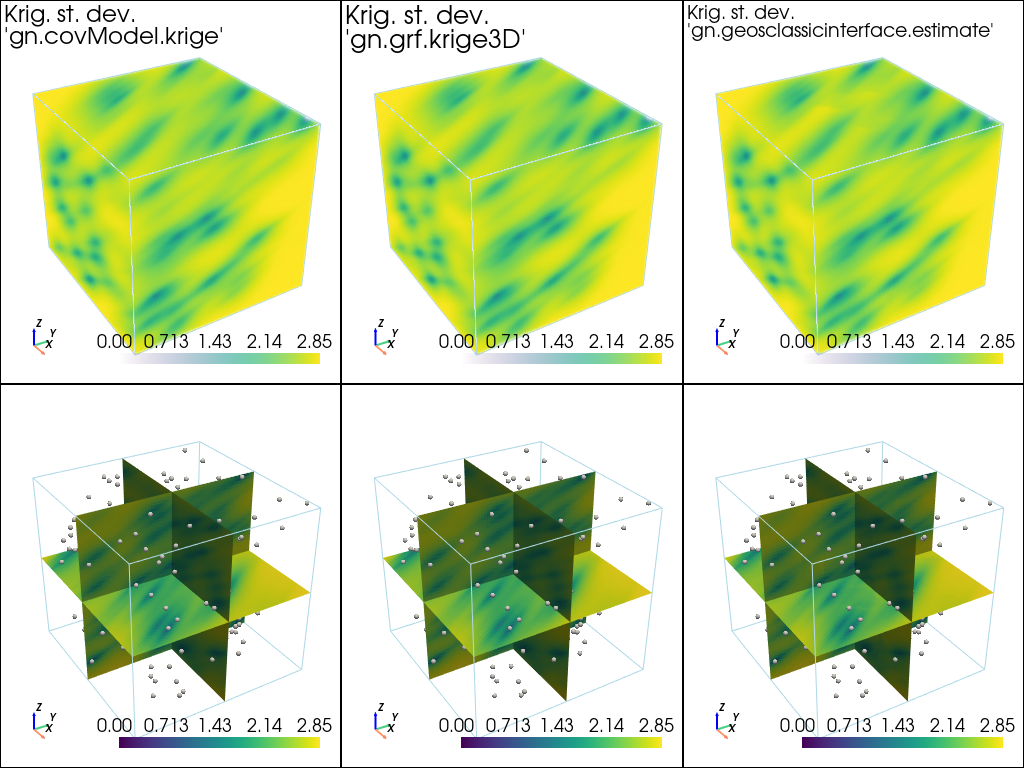

In [30]:
# Plot kriging standard deviation

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(2,3), notebook=False)
# ... inline
pp = pv.Plotter(shape=(2,3))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_krig, iv=1, 
    plotter=pp, 
    cmap='viridis',
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text="Krig. st. dev.\n'gn.covModel.krige'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_volume(
    im_grf, iv=1, 
    plotter=pp, 
    cmap='viridis',
    scalar_bar_kwargs={'title':' '}, # distinct title in each subplot for correct display!
    text="Krig. st. dev.\n'gn.grf.krige3D'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(0, 2)
gn.imgplot3d.drawImage3D_volume(
    im_gci, iv=1, 
    plotter=pp, 
    cmap='viridis',
    scalar_bar_kwargs={'title':'  '}, # distinct title in each subplot for correct display!
    text="Krig. st. dev.\n'gn.geosclassicinterface.estimate'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(1, 0)
gn.imgplot3d.drawImage3D_slice(
    im_krig, iv=1, 
    plotter=pp,
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap='viridis',
    scalar_bar_kwargs={'title':'   '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 1)
gn.imgplot3d.drawImage3D_slice(
    im_grf, iv=1, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap='viridis',
    scalar_bar_kwargs={'title':'    '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 2)
gn.imgplot3d.drawImage3D_slice(
    im_gci, iv=1, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap='viridis',
    scalar_bar_kwargs={'title':'     '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

In [31]:
print("Peak-to-peak estimation 'gn.covModel.krige - gn.grf.krige3D'                   = {}".format(np.ptp(im_krig.val[0] - im_grf.val[0])))
print("Peak-to-peak estimation 'gn.covModel.krige - gn.geosclassicinterface.estimate' = {}".format(np.ptp(im_krig.val[0] - im_gci.val[0])))
print("Peak-to-peak estimation 'gn.grf.krige3D    - gn.geosclassicinterface.estimate' = {}".format(np.ptp(im_grf.val[0] - im_gci.val[0])))
print("Peak-to-peak st. dev.   'gn.covModel.krige - gn.grf.krige3D'                   = {}".format(np.ptp(im_krig.val[1] - im_grf.val[1])))
print("Peak-to-peak st. dev.   'gn.covModel.krige - gn.geosclassicinterface.estimate' = {}".format(np.ptp(im_krig.val[1] - im_gci.val[1])))
print("Peak-to-peak st. dev.   'gn.grf.krige3D    - gn.geosclassicinterface.estimate' = {}".format(np.ptp(im_grf.val[1] - im_gci.val[1])))

Peak-to-peak estimation 'gn.covModel.krige - gn.grf.krige3D'                   = 0.045740572250433514
Peak-to-peak estimation 'gn.covModel.krige - gn.geosclassicinterface.estimate' = 3.591151533608848
Peak-to-peak estimation 'gn.grf.krige3D    - gn.geosclassicinterface.estimate' = 3.591151533608846
Peak-to-peak st. dev.   'gn.covModel.krige - gn.grf.krige3D'                   = 0.0001269298078985237
Peak-to-peak st. dev.   'gn.covModel.krige - gn.geosclassicinterface.estimate' = 0.3102542963297359
Peak-to-peak st. dev.   'gn.grf.krige3D    - gn.geosclassicinterface.estimate' = 0.3102542367250911


### Conditional simulation using the function `geone.grf.grf3D`
Via the function `geone.multiGaussian.multiGaussianRun`, with keyword arguments `mode='simulation', algo='fft'`.

In [32]:
np.random.seed(293)

t1 = time.time()
nreal = 20
im_sim_grf = gn.multiGaussian.multiGaussianRun(
                    cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
                    x=x, v=v,
                    mode='simulation', algo='fft', output_mode='img',
                    nreal=nreal)
# # Or:
# sim_grf = gn.grf.grf3D(
#                     cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
#                     x=x, v=v,
#                     nreal=nreal)
# im_sim_grf = gn.img.Img(nx, ny, nz, sx, sy, sz, ox, oy, oz, nv=nreal, val=sim_grf)
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

grf3D: do preliminary computation...
grf3D: compute circulant embedding...
grf3D: embedding dimension: 128 x 128 x 128
grf3D: compute FFT of circulant matrix...
grf3D: treatment of conditioning data...
grf3D: compute covariance matrix (rAA) for conditioning locations...
grf3D: compute index in the embedding grid for non-conditioning / conditioning locations...
Elapsed time: 6.4 sec


### Conditional simulation using the function `geone.geosclassicinterface.simulate`
Via the function `geone.multiGaussian.multiGaussianRun`, with keyword arguments `mode='simulation', algo='classic'`, and specifying the computational resources (`nproc` and `nthreads_per_proc`).

In [33]:
np.random.seed(293)

t1 = time.time()
nreal = 20
im_sim_gci = gn.multiGaussian.multiGaussianRun(
                    cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
                    x=x, v=v,
                    mode='simulation', algo='classic', output_mode='img',
                    method='simple_kriging',
                    nreal=nreal, 
                    nproc=4, nthreads_per_proc=4)
# # Or:
# sim_gci = gn.geosclassicinterface.simulate(
#                   cov_model_opt, (nx, ny, nz), (sx, sy, sz), (ox, oy, oz), 
#                   x=x, v=v, 
#                   method='simple_kriging',
#                   nreal=nreal, 
#                   nproc=4, nthreads_per_proc=4)
# im_sim_gci = sim_gci['image']
t2 = time.time()
print('Elapsed time: {:.2g} sec'.format(t2-t1))

simulate: pre-process data done: final number of data points : 150, inequality data points: 0
simulate: computational resources: nproc = 4, nthreads_per_proc = 4, nproc_sgs_at_ineq = 16
simulate: (Step 1) no inequality data
simulate: (Step 2) set new dataset gathering data and inequality data locations...
simulate: (Step 3) do kriging at the center of grid cells containing at least one data point...
simulate: (Step 4) do sgs (20 realizations) on the grid (at cell centers) using data points at cell centers...
simulate: call `run_MPDSOMPGeosClassicSim` [4 process(es) of 4 thread(s) (OpenMP)] ...
simulate: `run_MPDSOMPGeosClassicSim` [4 process(es)] complete
simulate: warnings encountered (14 times in all):
#  1: WARNING 02001: a neigbhor has been dropped (solving kriging system)
Elapsed time: 5.9 sec


### Plot some realizations and compare to the reference simulation

In [34]:
# min and max over all real and ref. sim
im_vmin = min(np.min(im_sim_grf.vmin()), np.min(im_sim_gci.vmin()), im_ref.vmin()[0]) 
im_vmax = max(np.max(im_sim_grf.vmax()), np.min(im_sim_gci.vmax()), im_ref.vmax()[0]) 

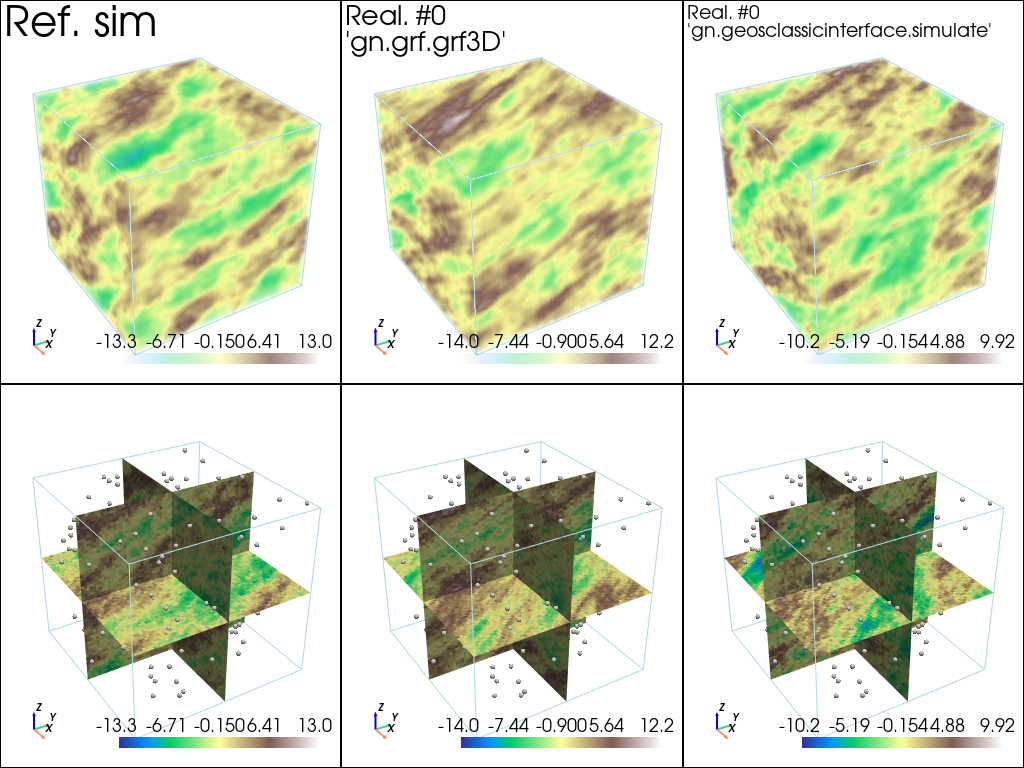

In [35]:
# Color settings
cmap = 'terrain'

# Plot "interactive in pop-up window" or "inline" (comment the undesired one) ...
# ... interactive (after closing the pop-up window, the position of the camera is retrieved in output)
#pp = pv.Plotter(shape=(2,3), notebook=False)
# ... inline
pp = pv.Plotter(shape=(2,3))

pp.subplot(0, 0)
gn.imgplot3d.drawImage3D_volume(
    im_ref, iv=0, 
    plotter=pp, 
    cmap=cmap,
    scalar_bar_kwargs={'title':''}, # distinct title in each subplot for correct display!
    text="Ref. sim") # title

pp.subplot(0, 1)
gn.imgplot3d.drawImage3D_volume(
    im_sim_grf, iv=0, 
    plotter=pp,
    cmap=cmap,
    scalar_bar_kwargs={'title':' '}, # distinct title in each subplot for correct display!
    text="Real. #0\n'gn.grf.grf3D'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(0, 2)
gn.imgplot3d.drawImage3D_volume(
    im_sim_gci, iv=0, 
    plotter=pp, 
    cmap=cmap,
    scalar_bar_kwargs={'title':'  '}, # distinct title in each subplot for correct display!
    text="Real. #0\n'gn.geosclassicinterface.simulate'", # title
    text_kwargs={'font_size':14}) # font size for title

pp.subplot(1, 0)
gn.imgplot3d.drawImage3D_slice(
    im_ref, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'   '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 1)
gn.imgplot3d.drawImage3D_slice(
    im_sim_grf, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'    '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.subplot(1, 2)
gn.imgplot3d.drawImage3D_slice(
    im_sim_gci, iv=0, 
    plotter=pp, 
    slice_normal_x=ox+(0.5+nx//2)*sx, # near central cell along x
    slice_normal_y=oy+(0.5+ny//2)*sy, # near central cell along y
    slice_normal_z=oz+(0.5+nz//2)*sz, # near central cell along z
    cmap=cmap,
    scalar_bar_kwargs={'title':'     '}, # distinct title in each subplot for correct display!
    text=None) # title                          
pp.add_mesh(data_points, color=(0.9, 0.9, 0.9), point_size=5., render_points_as_spheres=True)

pp.link_views()

pp.show(cpos=(165, -100, 115)) # position of the camera can be specified

The retained optimal covariance model has angles differing from those of the reference covariance model (which were considered unknown!), this is why the orientations of the structures slightly differ comparing the realizations above and the reference.

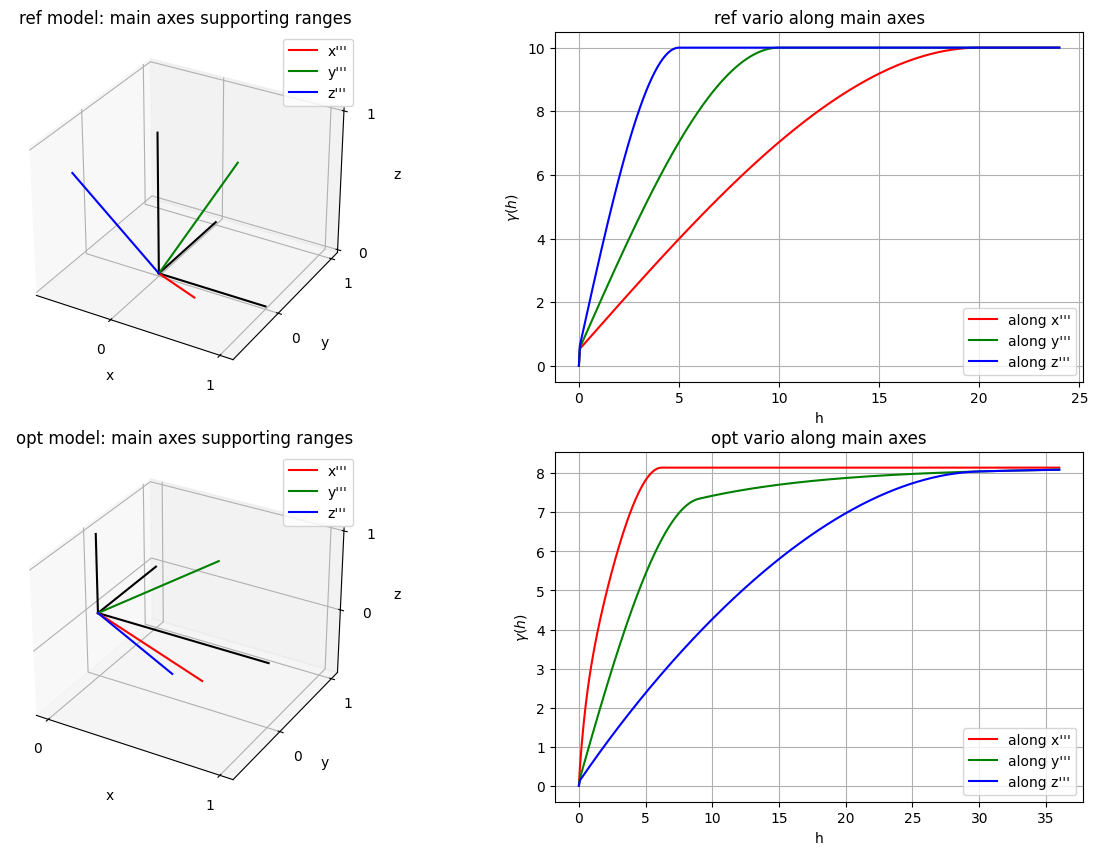

In [36]:
# Comparison of "optimal model" and "reference model"
fig = plt.figure(figsize=(15,10))

# ...plot main axes (ref model)
fig.add_subplot(2,2,1, projection='3d')
cov_model_ref.plot_mrot(set_3d_subplot=False)
plt.title('ref model: main axes supporting ranges')

# ...plot variogram model curves along each main axis (ref model)
fig.add_subplot(2,2,2)
cov_model_ref.plot_model_curves(vario=True)
plt.title('ref vario along main axes')

# ...plot main axes (opt model)
fig.add_subplot(2,2,3, projection='3d')
cov_model_opt.plot_mrot(set_3d_subplot=False)
plt.title('opt model: main axes supporting ranges')

# ...plot variogram model curves along each main axis (opt model)
fig.add_subplot(2,2,4)
cov_model_opt.plot_model_curves(vario=True)
plt.title('opt vario along main axes')

plt.show()